Saving archive.zip to archive.zip
User uploaded file "archive.zip" with length 29246 bytes
Extracted contents of archive.zip
Sales Dataset
    order_id       date  product_id    Category  Price  Quantity  Sales
0          1 2021-01-01           7       Mango     51         4    204
1          2 2021-01-01           9   Pineapple     55        10    550
2          3 2021-01-01           2     Avocado     33         4    132
3          4 2021-01-02          10  Watermelon     35         4    140
4          5 2021-01-03           3      Banana     39         7    273
..       ...        ...         ...         ...    ...       ...    ...
95        96 2021-01-30           1       Apple     37         4    148
96        97 2021-01-31           9   Pineapple     55         7    385
97        98 2021-01-31           6      Grapes     41         6    246
98        99 2021-01-31          10  Watermelon     35         4    140
99       100 2021-01-31           7       Mango     51         5    2

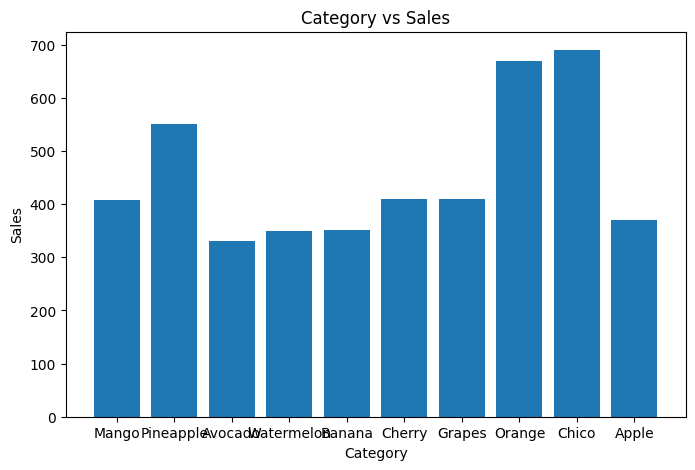

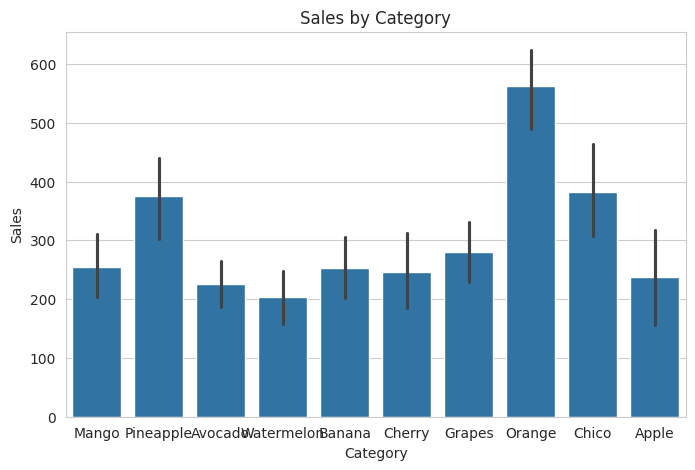

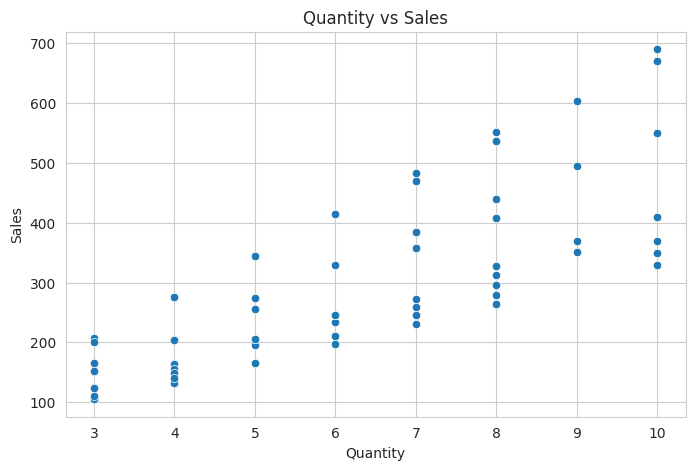

In [ ]:
# ===========================================
# SALES DATASET ANALYSIS
# ===========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import zipfile
import io
import os

# -------------------------------------------
# Load Sales Dataset
# -------------------------------------------

uploaded_files = files.upload()

# Process uploaded files, expecting a zip archive
for fn in uploaded_files.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded_files[fn])))

  if fn.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded_files[fn]), 'r') as zip_ref:
        zip_ref.extractall() # Extract all contents of the zip file
    print(f"Extracted contents of {fn}")
  else:
    # If it's not a zip, save it directly (in case sample_be_sales.xlsx was uploaded directly)
    with open(fn, 'wb') as f:
        f.write(uploaded_files[fn])

# Now, try to read the Excel file, assuming it's extracted or directly uploaded
df = pd.read_excel('sample_be_sales.xlsx', header=4) # Set header to 5th row (index 4)

# Rename columns to match expected names and calculate Sales
df = df.rename(columns={'product_name': 'Category', 'price_per_kg': 'Price', 'weight_kg': 'Quantity'})
df['Sales'] = df['Price'] * df['Quantity']

# Display Dataset
print("Sales Dataset")
print(df)

# ===========================================
# PANDAS (5 Functions)
# ===========================================

# 1. head()
print("\nFirst 5 Rows")
print(df.head())

# 2. info()
print("\nDataset Information")
print(df.info())

# 3. describe()
print("\nStatistical Summary")
print(df.describe())

# 4. shape
print("\nDataset Shape")
print(df.shape)

# 5. groupby()
print("\nTotal Sales by Category")
print(df.groupby("Category")["Sales"].sum())


# ===========================================
# NUMPY (5 Functions)
# ===========================================

sales = np.array(df["Sales"])

# 1. array()
print("\nSales Array")
print(sales)

# 2. sum()
print("\nTotal Sales")
print(np.sum(sales))

# 3. mean()
print("\nAverage Sales")
print(np.mean(sales))

# 4. max()
print("\nMaximum Sales")
print(np.max(sales))

# 5. min()
print("\nMinimum Sales")
print(np.min(sales))


# ===========================================
# MATPLOTLIB (5 Functions)
# ===========================================

# 1. figure()
plt.figure(figsize=(8,5))

# 2. bar()
plt.bar(df["Category"], df["Sales"])

# 3. title()
plt.title("Category vs Sales")

# 4. xlabel()
plt.xlabel("Category")

# 5. ylabel()
plt.ylabel("Sales")

plt.show()


# ===========================================
# SEABORN (5 Functions)
# ===========================================

# 1. set_style()
sns.set_style("whitegrid")

# 2. barplot()
plt.figure(figsize=(8,5))
sns.barplot(x="Category", y="Sales", data=df)

# 3. title()
plt.title("Sales by Category")

# 4. xlabel()
plt.xlabel("Category")

# 5. ylabel()
plt.ylabel("Sales")

plt.show()

# Extra Seaborn Graph
plt.figure(figsize=(8,5))
sns.scatterplot(x="Quantity", y="Sales", data=df)
plt.title("Quantity vs Sales")
plt.show()